In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from scipy import stats
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from src.data_loader import load_data, remove_nulls,show_duplicates,fill_nulls
from src.analysis import calculate_ema,calculate_sma,calculate_rsi



# LOAD DATA

In [2]:
df = load_data("../data/raw/Data/AAPL.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


#  DATA PREPARATION

In [3]:

# 1. Normalize timestamps (convert to timezone-naive)
# convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# make timezone-naive
df['Date'] = df['Date'].dt.tz_localize(None)

# verify
print(df['Date'].head())

# 2. Ensure columns are correctly typed
df = df.astype({'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'float64'})

0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[us]


# HANDLE MISSING VALUES


In [4]:
df = fill_nulls(df)
df = remove_nulls(df)
df.head()

No missing values found.


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

No missing values found. All 3774 rows kept.


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,7.460152e+08
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1.181608e+09
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1.289310e+09
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,7.530488e+08
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,6.735008e+08


# Technical Indicators with TA-Lib

In [5]:
df = df.sort_values('Date')
df = calculate_sma(
    df,
    column='Close',
    windows=[5, 10, 20]
)

# calculate EMA
df = calculate_ema(
    df,
    column='Close',
    windows=[5, 10, 20]
)

# display results
print(df.head(10))

        Date     Close      High       Low      Open        Volume     SMA_5  \
0 2009-01-02  2.721686  2.730385  2.554037  2.575630  7.460152e+08       NaN   
1 2009-01-05  2.836553  2.884539  2.780469  2.794266  1.181608e+09       NaN   
2 2009-01-06  2.789767  2.914229  2.770872  2.877641  1.289310e+09       NaN   
3 2009-01-07  2.729484  2.774170  2.706990  2.753477  7.530488e+08       NaN   
4 2009-01-08  2.780169  2.793666  2.700393  2.712090  6.735008e+08  2.771532   
5 2009-01-09  2.716589  2.800564  2.703393  2.795466  5.468456e+08  2.770512   
6 2009-01-12  2.659007  2.728886  2.625717  2.712990  6.177164e+08  2.735003   
7 2009-01-13  2.630514  2.691395  2.589726  2.646409  7.983976e+08  2.703153   
8 2009-01-14  2.559135  2.616717  2.540840  2.586427  1.021664e+09  2.669083   
9 2009-01-15  2.500652  2.522846  2.400782  2.416377  1.831634e+09  2.613179   

     SMA_10  SMA_20     EMA_5    EMA_10  EMA_20  
0       NaN     NaN       NaN       NaN     NaN  
1       NaN     NaN

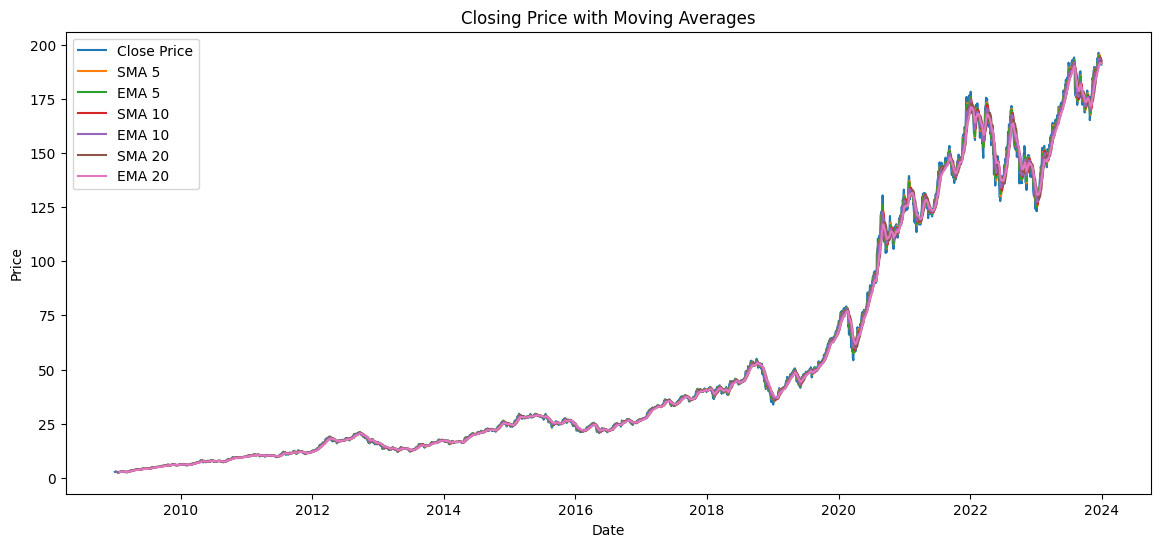

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], label='Close Price')

plt.plot(df['Date'], df['SMA_5'], label='SMA 5')
plt.plot(df['Date'], df['EMA_5'], label='EMA 5')
plt.plot(df['Date'], df['SMA_10'], label='SMA 10')
plt.plot(df['Date'], df['EMA_10'], label='EMA 10')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')
plt.xlabel("Date")
plt.ylabel("Price")

plt.title("Closing Price with Moving Averages")

plt.legend()

plt.show()

### Moving Average Analysis Summary

- The stock showed a strong long-term upward trend, especially after 2019.
- SMA and EMA closely followed the closing price, confirming the overall market direction.
- EMA reacted more quickly to short-term price fluctuations, while SMA appeared smoother and lagged slightly behind price movements.
- Periods where moving averages moved sharply upward reflected strong bullish momentum and increased market activity.
- Higher volatility was observed between 2020 and 2023, with larger price swings and rapid trend changes.

### Relative Strength Index(RSI)

In [7]:
df = calculate_rsi(
    df,
    column='Close',
    period=14
)